Lennard Jones potential truncated. 
PARAMETERS

In [3]:
import numpy as np
import math 
import matplotlib.pyplot as plt
from numba import njit
from mpl_toolkits.mplot3d import Axes3D

In [15]:
N = 200 #number of particles
epsilon = 1.0 
sigma = 1.0 
L = 10*sigma # box length
rho = N / L**3
rho = N / (L**3) #density 
time_mc = 2000
k_B = 1.0
T_star = 1.0
T =  T_star * (epsilon / k_B)
m = 1.0 # mass
start = 2**(1/6)
end = 4.0
step = 0.5
cutoffs = np.arange(start, end + step, step)
#cutoffs = np.round(cuts, 1)
#cutoffs = [start, 2.5, end]
time_scale = (m * sigma**2/ epsilon)**0.5
dt = 0.001 * time_scale
time_md = 6000
T_hb = 2

FUNCTIONS 

In [16]:
# LENNARD JONES POTENTIAL 
@njit
def lennard_jones_potential(r, sigma_cut):
    if r < sigma_cut:
        sr6 = (sigma / r) ** 6
        sr12 = (sigma / r) ** 12
        shift = 4 * epsilon * ((sigma / sigma_cut)**12 - (sigma / sigma_cut)**6) 
        return 4 * epsilon * (sr12 - sr6) - shift
    else: 
        return 0.0 
    

#####  Functions for MC evolution   #####
@njit
def initialize_distances(positions, box_length, N):
    distances = np.zeros((N, N)) 
    
    for i in range(N): #da zero a N - 1 
        for j in range(i + 1, N):
            drij = positions[i] - positions[j]
            drij = drij - np.round(drij / box_length) * box_length
            distances[i, j] = distances[j, i] = np.sqrt(drij[0]**2 + drij[1]**2 + drij[2]**2)
    return distances

# UPDATE DISTANCES
@njit
def update_distances(positions, distances, moved_index, box_length, N):
    for i in range(N):
        if i != moved_index:
            drij = positions[moved_index] - positions[i]
            drij = drij - np.round(drij / box_length) * box_length
            distances[moved_index, i] = distances[i, moved_index] = np.sqrt(drij[0]**2 + drij[1]**2 + drij[2]**2)
    return distances

# DISPLACE
@njit
def displace(energy, positions, distances, beta, box_length, sigma_cut, N):
    attempted = 0
    passed = 0
    rho = N / (box_length**3)
    for _ in range(N):  
        j = np.random.randint(0, N-1)  # randomly picked particle
        old_position = positions[j].copy()

        # Before displacemnt, I calculate the energy of the particles that are involved with lennard jones
        old_energy = 0.0
        for i in range(N):
            if i != j:
                old_energy += lennard_jones_potential(distances[j, i], sigma_cut)
        #old_energy = np.sum([lennard_jones_potential(d, sigma_cut) for d in distances[j,:] if d < sigma_cut])
        
        # Displacement is proposed according to the density 
        if (sigma_cut >= 2**(1/6) and sigma_cut < 2.5):  
            if rho > 0.1:    
                displacement = np.random.uniform(-1.3, 1.3, size=3)
            if rho <= 0.1 and rho > 0.05:
                displacement = np.random.uniform(-8, 8, size=3)
            if rho <= 0.05:
                displacement = np.random.uniform(-5, 5, size=3)
        else:
            displacement = np.random.uniform(-0.9, 0.9, size=3)
            
        #print(f"Spostamento proposto: {displacement}")
        positions[j] = positions[j] + displacement # (x + dx, y + dy, z + dz)
        # pbc
        positions[j] =  positions[j] - np.floor(positions[j] / box_length) * box_length
    
        #print(f"Nuova posizione particella {j}: {positions[j]}")

        # Update only distances that involve the shifted particle
        #print("Distanze prima dell'aggiornamento:", distances)
        distances = update_distances(positions, distances, j, box_length, N)
        #print("Distanze dopo l'aggiornamento:", distances)
    
        # Calcola energia dopo lo spostamento
        new_energy = 0.0
        #new_energy = np.sum([lennard_jones_potential(d, sigma_cut) for d in distances[j, :] if d < sigma_cut])
        for i in range(N):
            if i != j:
                new_energy += lennard_jones_potential(distances[j, i], sigma_cut)

        delta_E = new_energy - old_energy
    
    #print(f"Delta E: {delta_E}, Exp(-beta * Delta E): {np.exp(-beta * delta_E)}")
        attempted += 1
    
    # Metropolis
        if delta_E <= 0 or np.random.rand() <= np.exp(-beta * delta_E):
            passed += 1 # increment passed counter
            energy = energy + delta_E # update energy 
        else:
            positions[j] = old_position  # Go back to the original position before the shift
            distances = update_distances(positions, distances, j, box_length, N)  # Distances are restored as before the shift
            # energy = energy does not change
    return positions, distances, energy, passed, attempted # No change in the energy, so no deltaE



# THE SYSTEM EVOLVES WITH A MC UNTIL EQUILIBRATION, THEN MD BEGINS
def MC_evolution(T, steps, box_length, sigma_cut, N):
    total_energy = 0
    beta = 1 / (k_B * T)
    energies = []

    # Simulation starts with initial configuration of particles and initial distances among them
    positions = np.random.uniform(0, box_length, size=(N, 3))
    distances = initialize_distances(positions, box_length, N)
    # initial total energy of the configuration
    for i in range(N):
        for j in range(i + 1, N):
            total_energy += lennard_jones_potential(distances[i, j], sigma_cut) 

    for step in range(steps):    
        positions, distances, total_energy, passed, attempted = displace(total_energy, positions, distances, beta, box_length, sigma_cut, N)
        
        energies.append(total_energy)
        
        if step % 500 == 0: 
            print(f"Passo {step+1}/{steps}, Energia: {total_energy:.3f}, Accettazione: {passed / attempted:.2f}")

    return  energies, distances, positions



Plot functions 

In [ ]:
def plot_energy(energies):
    steps = len(energies)
    plt.figure(figsize=(10, 6))
    plt.plot(range(steps), energies, label='Energia totale', color='blue')
    plt.xlabel("Passi")
    plt.ylabel("Energia")
    plt.legend()
    plt.grid()
    plt.ylim(-500, 90)
    plt.tight_layout()
    plt.show()

def plot_positions_with_projections(positions, box_length):
    fig = plt.figure(figsize=(14, 10))

    # Plot 3D
    ax3d = fig.add_subplot(221, projection='3d')
    x = positions[:, 0]
    y = positions[:, 1]
    z = positions[:, 2]

    ax3d.scatter(x, y, z, c='b', marker='o', s=50, label='Particelle')
    ax3d.set_xlim([0, box_length])
    ax3d.set_ylim([0, box_length])
    ax3d.set_zlim([0, box_length])
    ax3d.set_xlabel('X')
    ax3d.set_ylabel('Y')
    ax3d.set_zlabel('Z')
    ax3d.set_title('Posizioni 3D')
    ax3d.legend()

    # Proiezione XY
    ax_xy = fig.add_subplot(222)
    ax_xy.scatter(x, y, c='r', marker='o', s=50, label='Proiezione XY')
    ax_xy.set_xlim([0, box_length])
    ax_xy.set_ylim([0, box_length])
    ax_xy.set_xlabel('X')
    ax_xy.set_ylabel('Y')
    ax_xy.set_title('Proiezione XY')
    ax_xy.legend()
    ax_xy.grid()

    # Proiezione XZ
    ax_xz = fig.add_subplot(223)
    ax_xz.scatter(x, z, c='g', marker='o', s=50, label='Proiezione XZ')
    ax_xz.set_xlim([0, box_length])
    ax_xz.set_ylim([0, box_length])
    ax_xz.set_xlabel('X')
    ax_xz.set_ylabel('Z')
    ax_xz.set_title('Proiezione XZ')
    ax_xz.legend()
    ax_xz.grid()

    # Proiezione YZ
    ax_yz = fig.add_subplot(224)
    ax_yz.scatter(y, z, c='m', marker='o', s=50, label='Proiezione YZ')
    ax_yz.set_xlim([0, box_length])
    ax_yz.set_ylim([0, box_length])
    ax_yz.set_xlabel('Y')
    ax_yz.set_ylabel('Z')
    ax_yz.set_title('Proiezione YZ')
    ax_yz.legend()
    ax_yz.grid()

    plt.tight_layout()
    plt.show()


# MD simulation

An initial thermalization is done via MC simulation. After that, MD simulation starts. INITIAL VELOCITIES HERE

In [ ]:
# INITIAL VELOCITIES: generation of initial velocities according to maxwell-boltzmann 
dev_vel = m / (k_B*T)
initial_velocities = np.random.normal(0, dev_vel, size=(N, 3)) # initialization of a matrix of initial velocities
tot_mom = np.sum(initial_velocities, axis=0) # total momentum
v_avg = tot_mom / N
initial_velocities = initial_velocities - v_avg # imposing total momentum = 0
 


# DERIVATIVE OF THE LENNARD JONES POTENTIAL
@njit
def dV_drij(r, sigma_cut):
    if r < sigma_cut:
        sr6 = (sigma / r) ** 6
        sr12 = sr6 ** 2
        fij = 24 * epsilon * (-2 * sr12 + sr6) / r
    else: 
        fij = 0.0
    return fij 



# FORCES AND POTENTIAL ENERGY FROM LJ POTENTIAL
@njit
def forces_and_Ep(positions, sigma_cut):
  # for each particle a force will be calculated
    forces = np.zeros_like(positions)  
    E_p = 0.0
  # calculation of the forces
    for i in range(N):
        for j in range(i+1, N):
            # particle i first -> fi
            rij = positions[i] - positions[j]
            rij = rij - np.round(rij / L) * L
            r = np.sqrt(rij[0]**2 + rij[1]**2 + rij[2]**2)
            if r > 0 : 
                fij = - dV_drij(r, sigma_cut) * rij / r 
                # summing forces acting on i from other particles 
                forces[i] += fij
                # summing forces acting on j
                forces[j] -= fij
                # potential energy from lennard jones
                E_p += lennard_jones_potential(r, sigma_cut)
    return forces, E_p



# INTEGRATION OF EOM WITH VELOCITY VERLET
@njit
def velocity_verl(positions, velocities, box_length, sigma, sigma_cut, steps, dt):
    energies = np.zeros(steps)
    # initial forces and potential energy 
    forces, E_p = forces_and_Ep(positions, sigma_cut)

    for step in range(steps):        
        positions = positions + velocities * dt + 0.5 * forces / m * dt**2
        positions = positions - np.floor(positions / box_length) * box_length
        new_forces, E_p = forces_and_Ep(positions, sigma_cut)
        velocities = velocities + 0.5 * (forces + new_forces) / m * dt
        forces = new_forces 

        kin_energy = 0.5 * m * np.sum(velocities**2)
        tot_energy = kin_energy + E_p
        energies[step] = tot_energy

        
        if step % 200 == 0:
            print("Step", step, "Energia totale:", tot_energy)
            
    E_mean = np.mean(energies)
    deviations = np.std(energies)
    #uncertainty = deviations / abs(E_mean)
    print(f"standard deviation:  {deviations}")
    print(f"mean energy:  {E_mean}")
   
    return positions, velocities, E_p, energies



# RADIAL DISTRIBUTION FUNCTION     
 
def radial_distribution(positions_list, L):
    rho  = N / L**3
    N_bins = 100  # Numero di bin fisso
    dr = (L/2) / N_bins  
    g_r_avg = np.zeros(N_bins)
    g_r_sum = np.zeros(N_bins)
    r_centers = np.linspace(0, L/2, N_bins)


    for positions in positions_list:
        g_r = np.zeros(N_bins)
        for i in range(N):
            for j in range(i + 1, N):  # Solo coppie i < j
                r_ij = positions[j] - positions[i]
                r_ij = r_ij - L * np.round(r_ij / L)  # pbc
                r = np.sqrt(r_ij[0]**2 + r_ij[1]**2 + r_ij[2]**2)  
                if r < L/2:
                    bin_index = int(r / dr)
                    g_r[bin_index] += 2  
    # normalization
        for k in range(N_bins):
            r_lower = k * dr
            r_upper = (k + 1) * dr
            V_shell = (4/3) * np.pi * (r_upper**3 - r_lower**3)
            g_r[k] /= rho * V_shell * len(positions)
    
        g_r_sum += g_r
# averaging over all the configurations
    g_r_avg = g_r_sum / len(positions_list)

    return r_centers, g_r_avg


In [16]:
# tesst calcolo forze
positions = np.array([[7.5, 7.8, 7.0], [7.0, 7.0, 7.0]])  # Due particelle lungo l'asse x
#forces, E_p = forces_and_Ep(positions, cutoffs[0])
forces = np.zeros_like(positions)
rij = positions[0] - positions[1]
rij = rij - np.round(rij / L) * L

r = np.sqrt(rij[0]**2 + rij[1]**2 + rij[2]**2)
if r > 0 : 
    fij = - dV_drij(r, cutoffs[0]) * rij / r 
    forces[0] += fij               
    forces[1] -= fij
print("Forze per due particelle:", forces)
print("distanza", rij)

Forze per due particelle: [[ 35.13430476  56.21488761   0.        ]
 [-35.13430476 -56.21488761   0.        ]]
distanza [0.5 0.8 0. ]


# SIMULATION WITH NO THERMOSTAT + RADIAL DISTRIBUTION

Passo 1/2000, Energia: 1583613.859, Accettazione: 0.57
Passo 501/2000, Energia: 7.474, Accettazione: 0.42
Passo 1001/2000, Energia: 11.732, Accettazione: 0.40
Passo 1501/2000, Energia: 9.501, Accettazione: 0.43
Step 0 Energia totale: 327.4624113657089
Step 200 Energia totale: 327.4631647591878
Step 400 Energia totale: 327.4627739713172
Step 600 Energia totale: 327.46180418176607
Step 800 Energia totale: 327.46351419731616
Step 1000 Energia totale: 327.46403786744526
Step 1200 Energia totale: 327.46319383006164
Step 1400 Energia totale: 327.4624579509719
Step 1600 Energia totale: 327.46308613402806
Step 1800 Energia totale: 327.4631430869176
Step 2000 Energia totale: 327.46335271475596
Step 2200 Energia totale: 327.46349297012864
Step 2400 Energia totale: 327.46324791390083
Step 2600 Energia totale: 327.4621591595412
Step 2800 Energia totale: 327.462999943473
Step 3000 Energia totale: 327.462777583313
Step 3200 Energia totale: 327.4631813735859
Step 3400 Energia totale: 327.463424793599

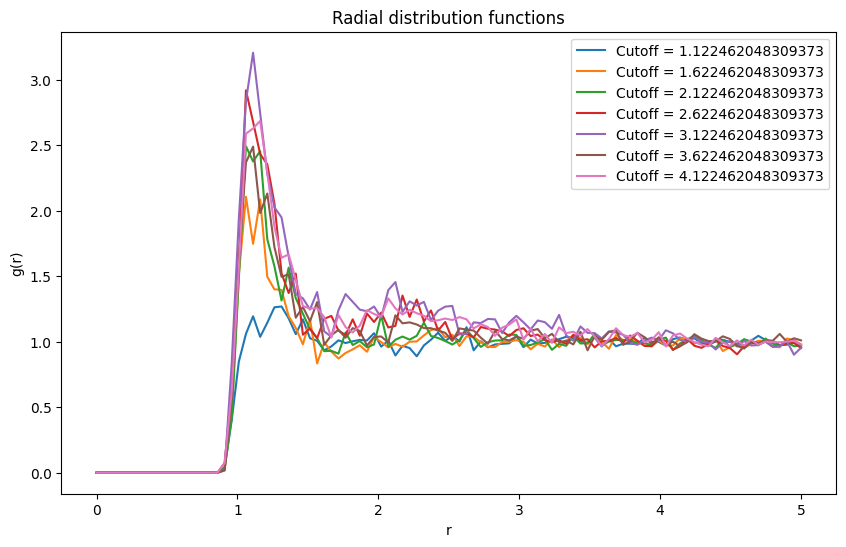

In [ ]:
#  --- --- SIMULATION --- ---
plt.figure(figsize=(10, 6))
for k in range(len(cutoffs)):

# --------------------- MC SIMULATION TO ARRIVE AT EQUILIBRIUM ---------------------------
    in_energies, in_distances, in_positions = MC_evolution(1, time_mc, L, cutoffs[k], N)

# SOME PLOTS
    #plot_positions_with_projections(in_positions, L)
    r = np.linspace(0.8, 3.0, 500)  
    V_array = np.zeros_like(r)
    for i in range(r.shape[0]):
        V_array[i] = lennard_jones_potential(r[i], cutoffs[k]) 
    # Plot del potenziale
    #plt.figure(figsize=(8, 6))
    #plt.plot(r, V_array, label=r'$V(r) = 4\epsilon \left[ \left( \frac{\sigma}{r} \right)^{12} - \left( \frac{\sigma}{r} \right)^6 \right]$')
    #plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
    #plt.xlabel('Distanza $r$', fontsize=14)
    #plt.ylabel('Potenziale $V(r)$', fontsize=14)    
    #plt.title('Potenziale di Lennard-Jones', fontsize=16)
    #plt.legend(fontsize=12)
    #plt.grid(True)
    #plt.ylim(-2, 2)  # Per evidenziare il minimo e il range utile
    #plt.xlim(0.8, 3.0)  # Range delle distanze
    #plt.show()

    
    # ----------------------------- MD SIMULATION -------------------------------------
    positions_list = [None]*5 # here positions will stored for the radial distribution function
    # 1000 iterarion of Velocity Verlet with time step 0.001
    final_positions, final_velocities, potentialenergy, energies = velocity_verl(
    in_positions, initial_velocities, L, sigma, cutoffs[k], time_md, dt)
    positions_list[0] = final_positions.copy()
    ascisse = len(energies)  
    #plt.figure(figsize=(10, 6))
    #plt.plot(range(ascisse), energies, label='Energia totale', color='blue')
    #plt.show()

    # Saving positions for the radial distribution function 
    for d in range(1, 5):
        final_positions, final_velocities, potentialenergy, energies = velocity_verl(
        final_positions, final_velocities, L, sigma, cutoffs[k], 1000, dt)
        positions_list[d] = final_positions.copy() 
        print("positions saved", d)

    # RADIAL DISTRIBUTION FUNCTION
    r_centers, g_r = radial_distribution(positions_list, L)
    plt.plot(r_centers, g_r, label=f'Cutoff = {cutoffs[k]}')
    
plt.xlabel("r")
plt.ylabel("g(r)")
plt.title("Radial distribution functions")
plt.legend()
plt.show()

# 2. THERMOSTATS

Now the temperature of the bath is T* = 2

In [ ]:
# -------- Velocity rescaling thermostat ---------
def velocity_rescaling(velocities, T_target):
    Tk = 1 / (3 * N * k_B) * m * np.sum(velocities**2)  
    l = np.sqrt(T_target / Tk) 
    velocities = velocities * l
    #print(f"lambda = {l},  T_k(t) = {Tk}")
    return velocities, Tk



# -------------  Andersen thermostat ---------------
def andersen(velocities, T_target, dt, omega, N):
    prob = omega * dt
    sigma_vel = np.sqrt(k_B * T_target / m)

    for i in range(N):
        r = np.random.rand()
        if r < prob:
            velocities[i] = np.random.normal(0, sigma_vel, size=3)

    return velocities 


# ----------------- VELOCITY VERLET FOR VELOCITY RESCALING ----------------------
def velocity_verl_rescaling(positions, velocities, L, N, sigma, cutoff, T_target, steps, dt):
    array_kinenergy = np.zeros(steps)
    temperature = np.zeros(steps)
    energies = np.zeros(steps)
    # initial forces and potential energy 
    forces, E_p = forces_and_Ep(positions, cutoff)

    for step in range(steps):        
        positions = positions + velocities * dt + 0.5 * forces / m * dt**2
        positions = positions - np.floor(positions / L) * L
        new_forces, E_p = forces_and_Ep(positions, cutoff)
        velocities = velocities + 0.5 * (forces + new_forces) / m * dt
        forces = new_forces 

        kin_energy = 0.5 * m * np.sum(velocities**2)
        tot_energy = kin_energy + E_p
        energies[step] = tot_energy

        #print(f"before rescaling  {velocities[0]}   {velocities[100]}")
        velocities, Tk = velocity_rescaling(velocities, T_target)
        if step % 500 == 0:
            print(f"step {step} / {steps}")
        #print(f"velocity rescaled {velocities[0]}   {velocities[100]}")
        
        temperature[step] = Tk
        array_kinenergy[step] = kin_energy
    
    # after having applied velocity verlet and rescaling many times: 
    n = len(temperature)
    fluct_temp = (np.sum(temperature**2) / n - np.mean(temperature)**2 ) / np.mean(temperature)**2        
    canonical_fluct = 2 / (3*N)
    E_mean = np.mean(energies)
    deviations = np.std(energies)
    uncertainty = deviations / abs(E_mean)
    expected = 3/2 * N * k_B * T_target
    E_kin_mean = np.mean(array_kinenergy)
    
    error_kinen = np.std(array_kinenergy)
    print(f"canonical fluctuation {canonical_fluct} vs velocity rescaling fluct {fluct_temp}")
    print(f"Errore relativo:  {uncertainty}")
    print(f"Mean kinetic energy:  {E_kin_mean} +/- {error_kinen}")
    print(f"compare with  {expected}")
   
    return positions, velocities, E_p, energies



# ------------------------------  VELOCITY VERLET FOR ANDERSEN -------------------------------
def velocity_verl_andersen(positions, velocities, L, N, cutoff, T_target, omega, steps, dt):
    energies = np.zeros(steps)
    array_kinenergy = np.zeros(steps)

    # initial forces and potential energy 
    forces, E_p = forces_and_Ep(positions, cutoff)

    for step in range(1, steps + 1):  

    # updating positions and velocities      
        positions = positions + velocities * dt + 0.5 * forces / m * dt**2
        positions = positions - np.floor(positions / L) * L
        new_forces, E_p = forces_and_Ep(positions, cutoff)
        velocities = velocities + 0.5 * (forces + new_forces) / m * dt
        forces = new_forces 

    # calculating kinetic energy
        kin_energy = 0.5 * m * np.sum(velocities**2)
        tot_energy = kin_energy + E_p
        energies[step - 1] = tot_energy
    
    # every 100 steps, apply andersen thermostat
        if step % 100 == 0:
            velocities = andersen(velocities, T_target, dt, omega, N)
            print(f'Andersen applied at step {step}')

        array_kinenergy[step] = kin_energy
    
    # mean energies         
    E_mean = np.mean(energies)
    E_kin_mean = np.mean(array_kinenergy)
    error_kinen = np.std(array_kinenergy)
    deviations = np.std(energies)
    uncertainty = deviations / abs(E_mean)
    expected = 3/2 * N * k_B * T_target

    print("Relative error = standard deviation / average energy:",  uncertainty)
    print(f"Mean kinetic energy:  {E_kin_mean} +/- {error_kinen}")
    print(f"compare with  {expected}")
   
    return positions, velocities, E_p, energies

Testing thermostats with different number of particles

# Velocity Rescaling 

N =200

In [22]:

in_energies, in_distances, in_positions = MC_evolution(1, time_mc, L, cutoffs[0], N) 
final_positions, final_velocities, potentialenergy, energies = velocity_verl_rescaling(
    in_positions, initial_velocities, L, N, sigma, cutoffs[0], T_hb, time_md, dt)


Passo 1/2000, Energia: 5632.699, Accettazione: 0.56
Passo 501/2000, Energia: 18.619, Accettazione: 0.46
Passo 1001/2000, Energia: 12.901, Accettazione: 0.40
Passo 1501/2000, Energia: 7.086, Accettazione: 0.43
lambda = 1.4488048159151834,  T_k(t) = 0.9528186161734528
step 0 / 6000
lambda = 1.0001711661238935,  T_k(t) = 1.9993155112513683
step 1 / 6000
lambda = 1.0001993813753745,  T_k(t) = 1.9992027129527072
step 2 / 6000
lambda = 1.0002280993144517,  T_k(t) = 1.9990879148230611
step 3 / 6000
lambda = 1.000257517718962,  T_k(t) = 1.99897032687983
step 4 / 6000
lambda = 1.0002874385898568,  T_k(t) = 1.9988507411763112
step 5 / 6000
lambda = 1.0003176277193737,  T_k(t) = 1.9987300941904582
step 6 / 6000
lambda = 1.000347966108518,  T_k(t) = 1.9986088617114957
step 7 / 6000
lambda = 1.0003784428055535,  T_k(t) = 1.9984870876581318
step 8 / 6000
lambda = 1.0004088756626972,  T_k(t) = 1.9983654998784914
step 9 / 6000
lambda = 1.0004386897771107,  T_k(t) = 1.9982463949088478
step 10 / 6000
la

----     N =170   -----

In [23]:
in_energies, in_distances, in_positions = MC_evolution(1, time_mc, L, cutoffs[0], N) 
final_positions, final_velocities, potentialenergy, energies = velocity_verl_rescaling(
    in_positions, initial_velocities, L, N, sigma, cutoffs[0], T_hb, time_md, dt)


Passo 1/2000, Energia: 5964.481, Accettazione: 0.58
Passo 501/2000, Energia: 10.012, Accettazione: 0.48
Passo 1001/2000, Energia: 7.282, Accettazione: 0.46
Passo 1501/2000, Energia: 5.245, Accettazione: 0.49
step 0 / 6000
step 500 / 6000
step 1000 / 6000
step 1500 / 6000
step 2000 / 6000
step 2500 / 6000
step 3000 / 6000
step 3500 / 6000
step 4000 / 6000
step 4500 / 6000
step 5000 / 6000
step 5500 / 6000
canonical fluctuation 0.00392156862745098 vs velocity rescaling fluct 4.9427383624751526e-05
Errore relativo:  0.013083968130011248
Mean kinetic energy:  509.9517263897016 +/- 3.5851957877990412
compare with  510.0


--- N = 100 ----

In [9]:
in_energies, in_distances, in_positions = MC_evolution(1, time_mc, L, cutoffs[0], N) 
final_positions, final_velocities, potentialenergy, energies = velocity_verl_rescaling(
    in_positions, initial_velocities, L, N, sigma, cutoffs[0], T_hb, time_md, dt)


Passo 1/2000, Energia: 1038269315.853, Accettazione: 0.61
Passo 501/2000, Energia: 2.888, Accettazione: 0.63
Passo 1001/2000, Energia: 1.569, Accettazione: 0.68
Passo 1501/2000, Energia: 1.498, Accettazione: 0.53
step 0 / 6000
step 500 / 6000
step 1000 / 6000
step 1500 / 6000
step 2000 / 6000
step 2500 / 6000
step 3000 / 6000
step 3500 / 6000
step 4000 / 6000
step 4500 / 6000
step 5000 / 6000
step 5500 / 6000
canonical fluctuation 0.006666666666666667 vs velocity rescaling fluct 5.0968583484152505e-05
Errore relativo:  0.013791298960528752
Mean kinetic energy:  299.9730809471499 +/- 2.141576366823863
compare with  300.0


--- N = 140 ----

In [14]:
in_energies, in_distances, in_positions = MC_evolution(1, time_mc, L, cutoffs[0], N) 
final_positions, final_velocities, potentialenergy, energies = velocity_verl_rescaling(
    in_positions, initial_velocities, L, N, sigma, cutoffs[0], T_hb, time_md, dt)

Passo 1/2000, Energia: 27685.600, Accettazione: 0.62
Passo 501/2000, Energia: 4.482, Accettazione: 0.61
Passo 1001/2000, Energia: 3.952, Accettazione: 0.53
Passo 1501/2000, Energia: 2.958, Accettazione: 0.59
step 0 / 6000
step 500 / 6000
step 1000 / 6000
step 1500 / 6000
step 2000 / 6000
step 2500 / 6000
step 3000 / 6000
step 3500 / 6000
step 4000 / 6000
step 4500 / 6000
step 5000 / 6000
step 5500 / 6000
canonical fluctuation 0.004761904761904762 vs velocity rescaling fluct 4.79915700398977e-05
Errore relativo:  0.012118610847185067
Mean kinetic energy:  419.9626194095011 +/- 2.909330868319854
compare with  420.0


# Andersen

N = 200

In [27]:
in_energies, in_distances, in_positions = MC_evolution(1, time_mc, L, cutoffs[0], N)
final_positions, final_velocities, potentialenergy, energies =  velocity_verl_andersen(
    in_positions, initial_velocities, L, N, cutoffs[0], T_hb, 10, time_md, dt)


Passo 1/2000, Energia: 35596755256.401, Accettazione: 0.54
Passo 501/2000, Energia: 8.153, Accettazione: 0.41
Passo 1001/2000, Energia: 9.787, Accettazione: 0.46
Passo 1501/2000, Energia: 12.133, Accettazione: 0.43
Andersen applied at step 100
Andersen applied at step 200
Andersen applied at step 300
Andersen applied at step 400
Andersen applied at step 500
Andersen applied at step 600
Andersen applied at step 700
Andersen applied at step 800
Andersen applied at step 900
Andersen applied at step 1000
Andersen applied at step 1100
Andersen applied at step 1200
Andersen applied at step 1300
Andersen applied at step 1400
Andersen applied at step 1500
Andersen applied at step 1600
Andersen applied at step 1700
Andersen applied at step 1800
Andersen applied at step 1900
Andersen applied at step 2000
Andersen applied at step 2100
Andersen applied at step 2200
Andersen applied at step 2300
Andersen applied at step 2400
Andersen applied at step 2500
Andersen applied at step 2600
Andersen appli

IndexError: index 5700 is out of bounds for axis 0 with size 5700